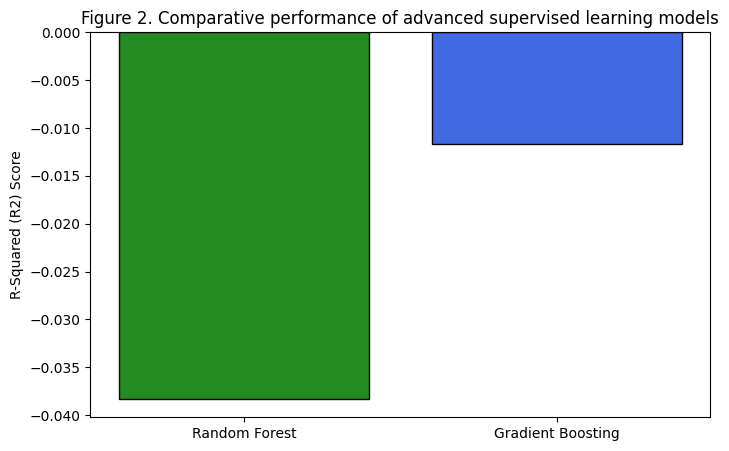

RQ2 Complete! Files saved in /kaggle/working/


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Dataset
df = pd.read_csv('/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv')

# 2. Basic Cleaning (IDs drop karein)
cols_to_drop = ['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords']
df_clean = df.drop(columns=cols_to_drop)
df_clean = pd.get_dummies(df_clean, columns=['Subscription_Tier'], drop_first=True)

# 3. Features and Target
X = df_clean.drop(columns=['Revenue_Generated'])
y = df_clean['Revenue_Generated']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Advanced Models (RQ2 focus)
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 5. Training and Comparison
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_test, preds), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        "R2": round(r2_score(y_test, preds), 4)
    })

# 6. Save Table II
table_rq2 = pd.DataFrame(results)
table_rq2.to_csv('RQ2_Comparison_Table.csv', index=False)

# 7. Save Figure 2
plt.figure(figsize=(8, 5))
plt.bar(table_rq2["Model"], table_rq2["R2"], color=['forestgreen', 'royalblue'], edgecolor='black')
plt.title('Figure 2. Comparative performance of advanced supervised learning models')
plt.ylabel('R-Squared (R2) Score')
plt.savefig('RQ2_Comparison_Plot.pdf')
plt.show()

print("RQ2 Complete! Files saved in /kaggle/working/")